In [ ]:
!pip install woe xverse scikit-learn pandas numpy

In [ ]:
# Cell 1: Imports and Load Data
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import warnings
from google.colab import drive

drive.mount('/content/drive')
warnings.filterwarnings('ignore')

# Load data
df = pd.read_csv('/content/drive/MyDrive/credit_risk_analysis/data/raw/data.csv')
print(f"Shape: {df.shape}")
print(df.dtypes)
print(df.head(20))

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Shape: (95662, 16)
TransactionId            object
BatchId                  object
AccountId                object
SubscriptionId           object
CustomerId               object
CurrencyCode             object
CountryCode               int64
ProviderId               object
ProductId                object
ProductCategory          object
ChannelId                object
Amount                  float64
Value                     int64
TransactionStartTime     object
PricingStrategy           int64
FraudResult               int64
dtype: object
           TransactionId         BatchId       AccountId       SubscriptionId  \
0    TransactionId_76871   BatchId_36123  AccountId_3957   SubscriptionId_887   
1    TransactionId_73770   BatchId_15642  AccountId_4841  SubscriptionId_3829   
2    TransactionId_26203   BatchId_53941  AccountId_4229   SubscriptionId_222   
3 

In [ ]:
# Parse dates and add basic time features
df['TransactionStartTime'] = pd.to_datetime(df['TransactionStartTime'])
df['TransactionHour'] = df['TransactionStartTime'].dt.hour
df['TransactionDay'] = df['TransactionStartTime'].dt.day
df['TransactionMonth'] = df['TransactionStartTime'].dt.month
df['TransactionYear'] = df['TransactionStartTime'].dt.year

print("Updated dtypes (after parsing):\n", df.dtypes)

print("\nOverview (Summary Statistics):\n")
print(df.describe(include='all'))  # Central tendency, dispersion for all cols

print("\nMissing Values:\n", df.isnull().sum())  # Total missing per col

Updated dtypes (after parsing):
 TransactionId                        object
BatchId                              object
AccountId                            object
SubscriptionId                       object
CustomerId                           object
CurrencyCode                         object
CountryCode                           int64
ProviderId                           object
ProductId                            object
ProductCategory                      object
ChannelId                            object
Amount                              float64
Value                                 int64
TransactionStartTime    datetime64[ns, UTC]
PricingStrategy                       int64
FraudResult                           int64
TransactionHour                       int32
TransactionDay                        int32
TransactionMonth                      int32
TransactionYear                       int32
dtype: object

Overview (Summary Statistics):

              TransactionId        Batch

In [ ]:
print(df.columns)
print(df.head())

Index(['TransactionId', 'BatchId', 'AccountId', 'SubscriptionId', 'CustomerId',
       'CurrencyCode', 'CountryCode', 'ProviderId', 'ProductId',
       'ProductCategory', 'ChannelId', 'Amount', 'Value',
       'TransactionStartTime', 'PricingStrategy', 'FraudResult',
       'TransactionHour', 'TransactionDay', 'TransactionMonth',
       'TransactionYear'],
      dtype='object')
         TransactionId         BatchId       AccountId       SubscriptionId  \
0  TransactionId_76871   BatchId_36123  AccountId_3957   SubscriptionId_887   
1  TransactionId_73770   BatchId_15642  AccountId_4841  SubscriptionId_3829   
2  TransactionId_26203   BatchId_53941  AccountId_4229   SubscriptionId_222   
3    TransactionId_380  BatchId_102363   AccountId_648  SubscriptionId_2185   
4  TransactionId_28195   BatchId_38780  AccountId_4841  SubscriptionId_3829   

        CustomerId CurrencyCode  CountryCode    ProviderId     ProductId  \
0  CustomerId_4406          UGX          256  ProviderId_6  ProductI

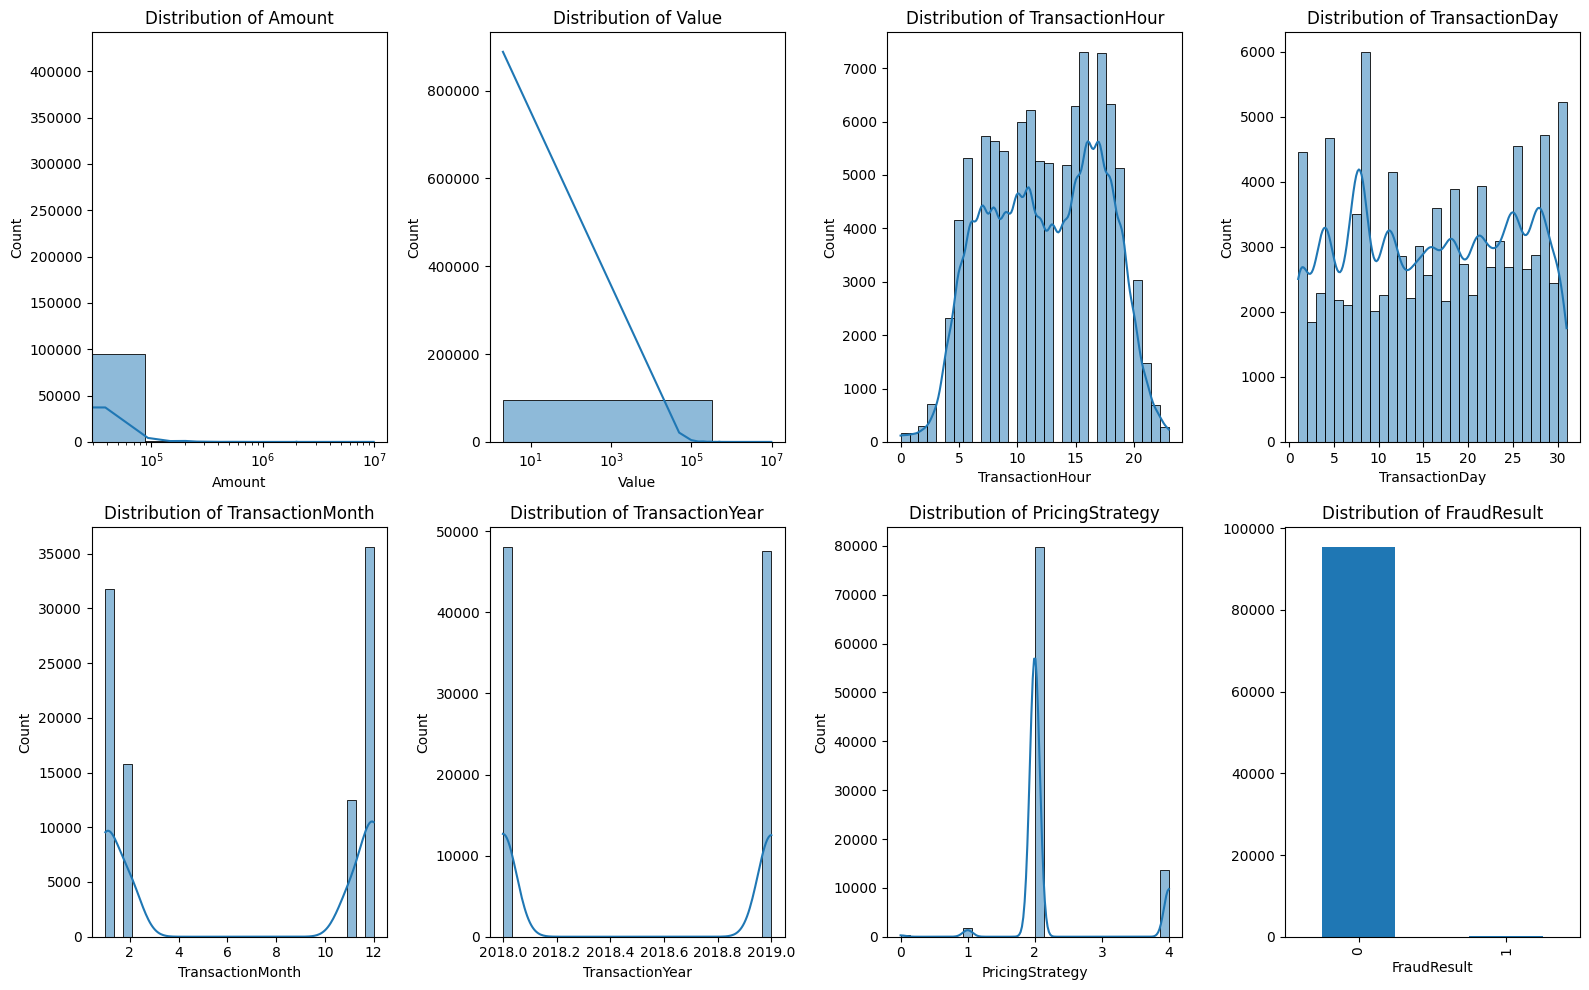


Skewness ( >1 = right-skewed, good for log-transform in feats):

Amount: 51.098
Value: 51.291
TransactionHour: -0.091
TransactionDay: -0.013
TransactionMonth: -0.013
PricingStrategy: 1.659


In [ ]:
# Numerical cols for dist (from describe + time feats)
num_cols = ['Amount', 'Value', 'TransactionHour', 'TransactionDay', 'TransactionMonth', 'TransactionYear', 'PricingStrategy', 'FraudResult']

# Histograms with KDE
fig, axes = plt.subplots(2, 4, figsize=(16, 10))
axes = axes.ravel()  # Flatten for easy indexing

for i, col in enumerate(num_cols):
    ax = axes[i]
    if col in ['FraudResult']:  # Bar for binary
        df[col].value_counts().plot(kind='bar', ax=ax)
    else:
        sns.histplot(data=df, x=col, kde=True, bins=30, ax=ax)
    ax.set_title(f'Distribution of {col}')
    ax.set_xlabel(col)
    if col == 'Amount' or col == 'Value':  # Log scale for skew
        ax.set_xscale('log')

plt.tight_layout()
plt.savefig('/content/eda_dist_num.png', dpi=150, bbox_inches='tight')  # Save for demo
plt.show()

# Quick print: Skewness for nums
print("\nSkewness ( >1 = right-skewed, good for log-transform in feats):\n")
skew_cols = ['Amount', 'Value', 'TransactionHour', 'TransactionDay', 'TransactionMonth', 'PricingStrategy']
for col in skew_cols:
    print(f"{col}: {df[col].skew():.3f}")

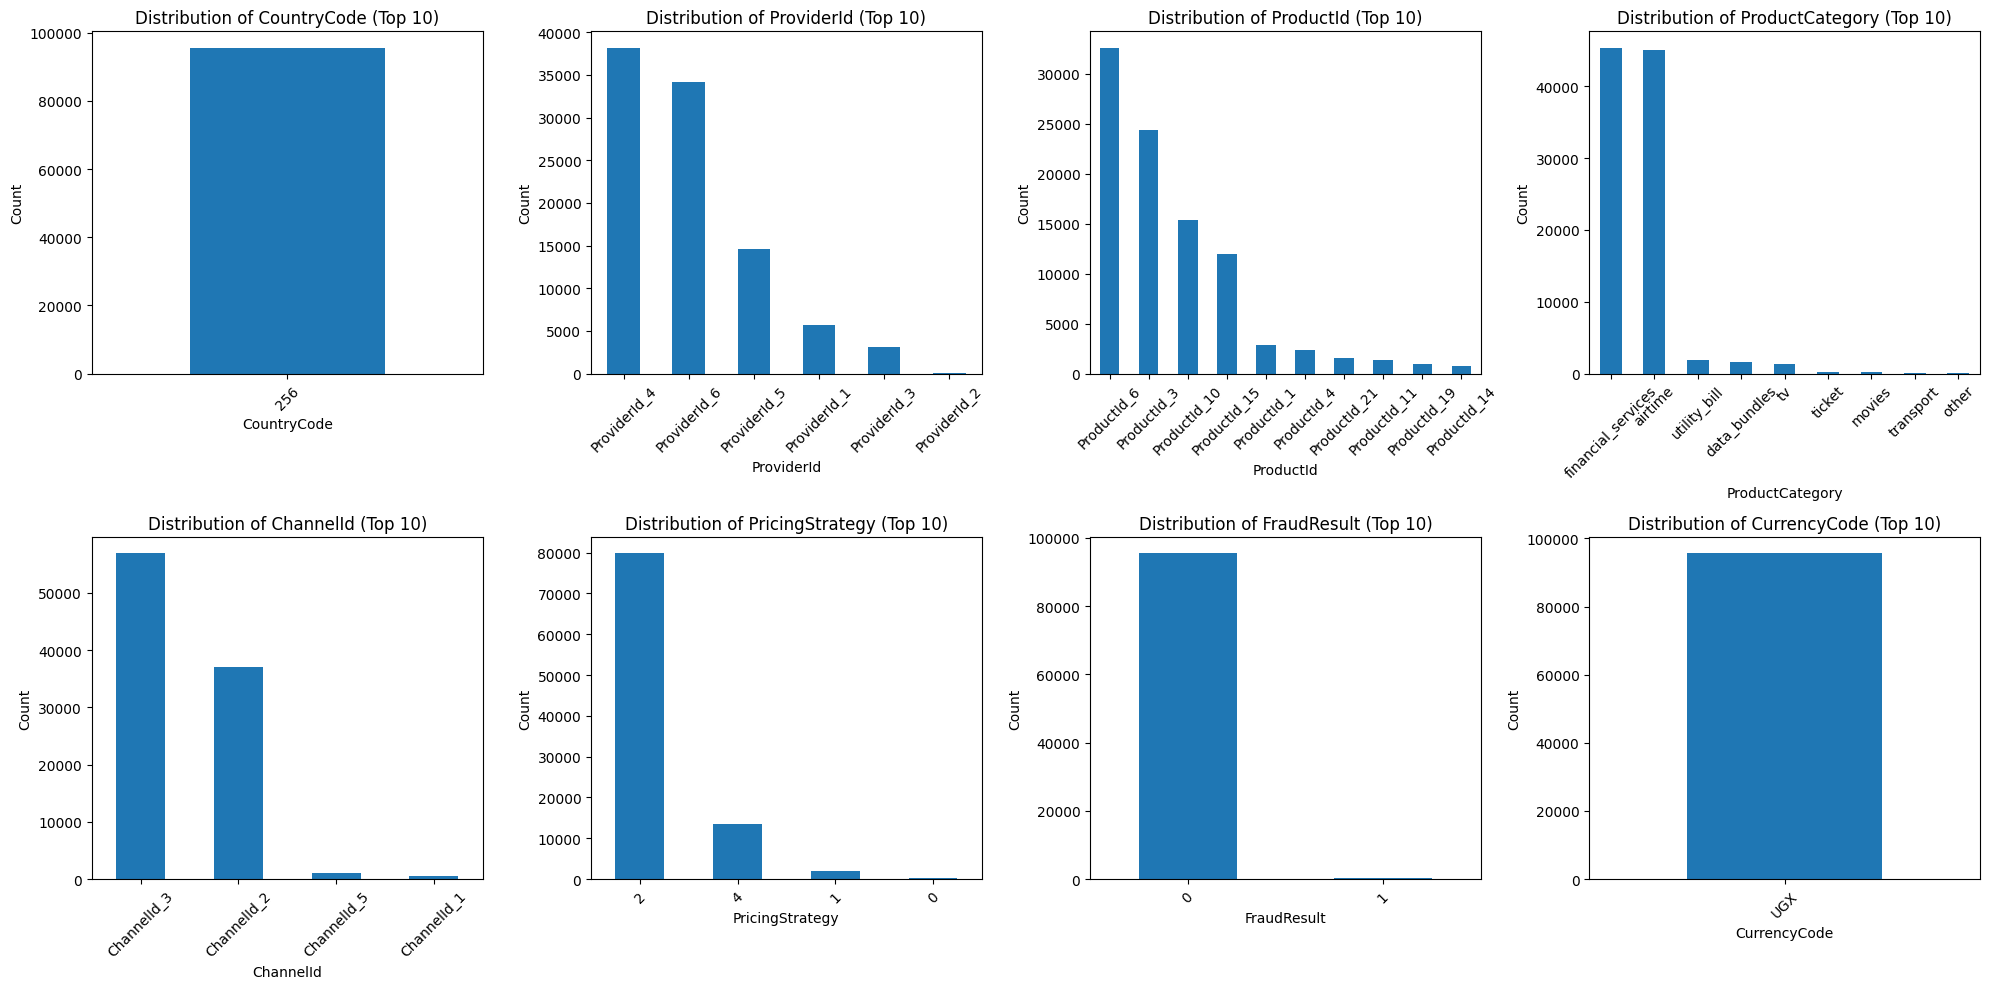


Top Categories (for feature eng notes):

CountryCode:
CountryCode
256    95662
Name: count, dtype: int64

ProviderId:
ProviderId
ProviderId_4    38189
ProviderId_6    34186
ProviderId_5    14542
Name: count, dtype: int64

ProductId:
ProductId
ProductId_6     32635
ProductId_3     24344
ProductId_10    15384
Name: count, dtype: int64

ProductCategory:
ProductCategory
financial_services    45405
airtime               45027
utility_bill           1920
Name: count, dtype: int64

ChannelId:
ChannelId
ChannelId_3    56935
ChannelId_2    37141
ChannelId_5     1048
Name: count, dtype: int64

PricingStrategy:
PricingStrategy
2    79848
4    13562
1     1867
Name: count, dtype: int64

FraudResult:
FraudResult
0    95469
1      193
Name: count, dtype: int64

CurrencyCode:
CurrencyCode
UGX    95662
Name: count, dtype: int64



In [ ]:
# Categorical cols (from describe: low-cardinality for bars)
cat_cols = ['CountryCode', 'ProviderId', 'ProductId', 'ProductCategory', 'ChannelId', 'PricingStrategy', 'FraudResult', 'CurrencyCode']

# Bar plots for frequencies
fig, axes = plt.subplots(2, 4, figsize=(20, 10))
axes = axes.ravel()

for i, col in enumerate(cat_cols):
    ax = axes[i]
    value_counts = df[col].value_counts().head(10)  # Top 10 to avoid clutter (e.g., ProductId has 23 uniques)
    value_counts.plot(kind='bar', ax=ax)
    ax.set_title(f'Distribution of {col} (Top 10)')
    ax.set_xlabel(col)
    ax.set_ylabel('Count')
    ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig('/content/eda_dist_cat.png', dpi=150, bbox_inches='tight')  # Save for demo
plt.show()

# Quick print: Top categories
print("\nTop Categories (for feature eng notes):\n")
for col in cat_cols:
    top = df[col].value_counts().head(3)
    print(f"{col}:\n{top}\n")

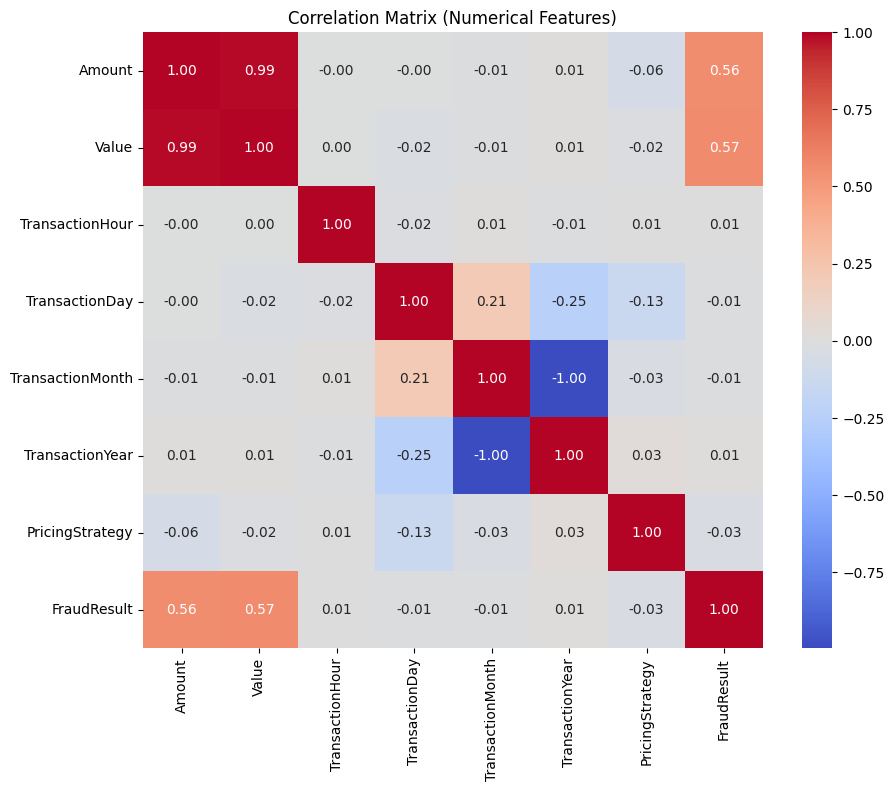


Correlation Highlights (abs > 0.1):

             level_0           level_1         0
1             Amount             Value  0.989692
2             Amount       FraudResult  0.557370
3              Value            Amount  0.989692
5              Value       FraudResult  0.566739
8     TransactionDay  TransactionMonth  0.207837
9     TransactionDay   TransactionYear -0.247493
10    TransactionDay   PricingStrategy -0.131597
11  TransactionMonth    TransactionDay  0.207837
13  TransactionMonth   TransactionYear -0.996205
14   TransactionYear    TransactionDay -0.247493
15   TransactionYear  TransactionMonth -0.996205
17   PricingStrategy    TransactionDay -0.131597
19       FraudResult            Amount  0.557370
20       FraudResult             Value  0.566739


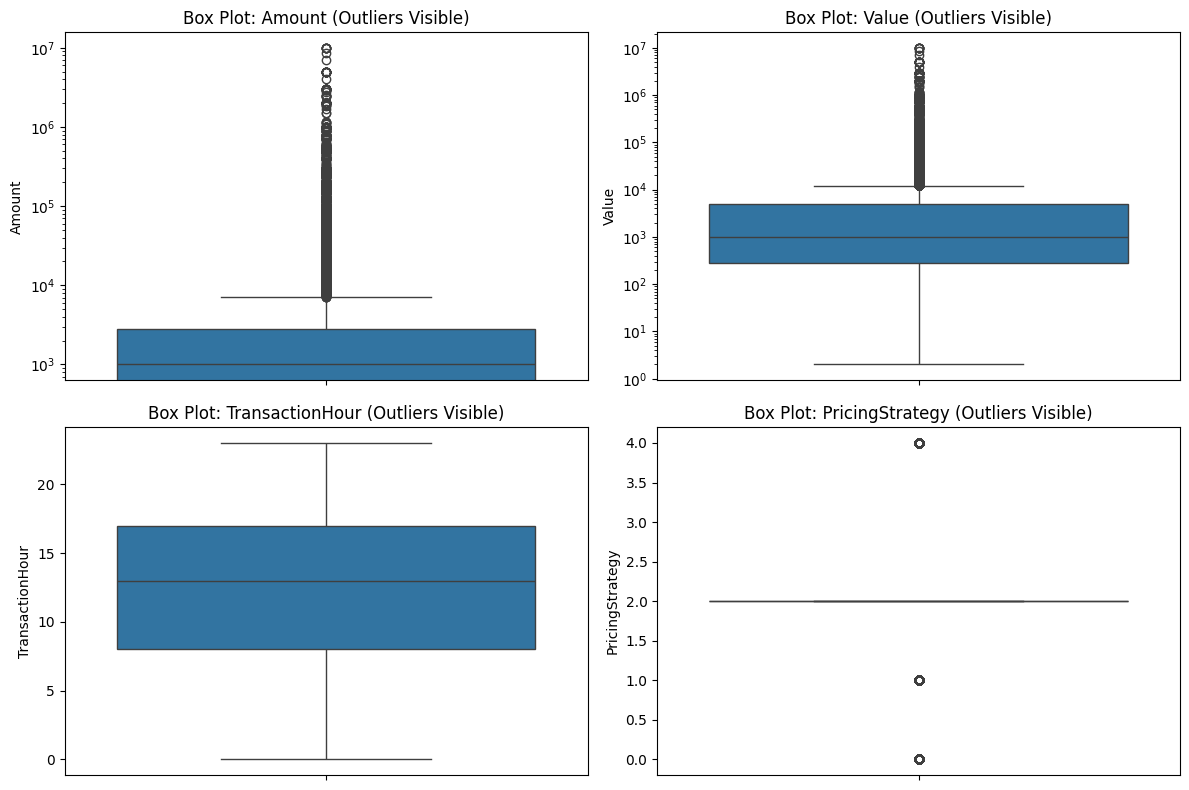


Outlier Counts (IQR > 1.5):

Amount: 24441 (25.5%)
Value: 9021 (9.4%)
TransactionHour: 0 (0.0%)
PricingStrategy: 15814 (16.5%)


In [ ]:
# Correlation: Num cols + Fraud (for risk proxy ideas)
num_for_corr = ['Amount', 'Value', 'TransactionHour', 'TransactionDay', 'TransactionMonth', 'TransactionYear', 'PricingStrategy', 'FraudResult']
corr_matrix = df[num_for_corr].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0, fmt='.2f')
plt.title('Correlation Matrix (Numerical Features)')
plt.savefig('/content/eda_corr.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nCorrelation Highlights (abs > 0.1):\n")
high_corr = corr_matrix[abs(corr_matrix) > 0.1].stack().reset_index()
high_corr = high_corr[high_corr['level_0'] != high_corr['level_1']]  # No self
print(high_corr)

# Outliers: Box plots
outlier_cols = ['Amount', 'Value', 'TransactionHour', 'PricingStrategy']  # Skip days/months (uniform)
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.ravel()

for i, col in enumerate(outlier_cols):
    ax = axes[i]
    sns.boxplot(data=df, y=col, ax=ax)
    ax.set_title(f'Box Plot: {col} (Outliers Visible)')
    if col in ['Amount', 'Value']:
        ax.set_yscale('log')  # Log to compress tails

plt.tight_layout()
plt.savefig('/content/eda_outliers.png', dpi=150, bbox_inches='tight')
plt.show()

# Quick outlier count (IQR method)
print("\nOutlier Counts (IQR > 1.5):\n")
for col in outlier_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    outliers = df[(df[col] < (Q1 - 1.5 * IQR)) | (df[col] > (Q3 + 1.5 * IQR))]
    print(f"{col}: {len(outliers)} ({len(outliers)/len(df)*100:.1f}%)")

In [ ]:
print(df.head())

         TransactionId         BatchId       AccountId       SubscriptionId  \
0  TransactionId_76871   BatchId_36123  AccountId_3957   SubscriptionId_887   
1  TransactionId_73770   BatchId_15642  AccountId_4841  SubscriptionId_3829   
2  TransactionId_26203   BatchId_53941  AccountId_4229   SubscriptionId_222   
3    TransactionId_380  BatchId_102363   AccountId_648  SubscriptionId_2185   
4  TransactionId_28195   BatchId_38780  AccountId_4841  SubscriptionId_3829   

        CustomerId CurrencyCode  CountryCode    ProviderId     ProductId  \
0  CustomerId_4406          UGX          256  ProviderId_6  ProductId_10   
1  CustomerId_4406          UGX          256  ProviderId_4   ProductId_6   
2  CustomerId_4683          UGX          256  ProviderId_6   ProductId_1   
3   CustomerId_988          UGX          256  ProviderId_1  ProductId_21   
4   CustomerId_988          UGX          256  ProviderId_4   ProductId_6   

      ProductCategory    ChannelId   Amount  Value  TransactionStart

In [ ]:
# Save processed snapshot (with parsed datetime + time features)
processed_path = '/content/drive/MyDrive/credit_risk_analysis/data/processed/eda_snapshot.csv'
df.to_csv(processed_path, index=False)
print(f"Processed snapshot saved to {processed_path}")


Processed snapshot saved to /content/drive/MyDrive/credit_risk_analysis/data/processed/eda_snapshot.csv
